In [ ]:
# !pip uninstall -y gensim
# !pip install gensim==4.3.2 numpy==1.25.2 scipy==1.10.1 --upgrade --force-reinstall

# PADL coursework

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, MinMaxScaler
from sklearn.model_selection import train_test_split
from scipy.stats import zscore

from sklearn.metrics import r2_score, accuracy_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

# from gensim.models import Word2Vec

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import SelectKBest, f_regression

import os
from PIL import Image
import torchvision.transforms as transforms
from torch.utils.data import Dataset
from torch.utils.data import random_split
from torchvision import models
from collections import Counter
from sklearn.model_selection import StratifiedShuffleSplit

from skimage.metrics import structural_similarity as ssim

PROJECT_DIRECTORY = '/content/drive/MyDrive/padl_ws/'
DATA_DIRECTORY = PROJECT_DIRECTORY + "data/"
MODEL_DIRECTORY = PROJECT_DIRECTORY + "models/"

Mounted at /content/drive/


## Q1

### A

In [ ]:
# Get data from PADL-Q11-train.csv
data = np.loadtxt((DATA_DIRECTORY + '/PADL-Q11-train.csv'), delimiter=',', skiprows=1)
# Load header to get feature names
header = np.genfromtxt(DATA_DIRECTORY + '/PADL-Q11-train.csv', delimiter=',', max_rows=1, dtype=str)

# Split data into features and targets and feature names
X = data[:, :-1]
y = data[:, -1]
feature_names = header[:-1]

# Split the available data into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1)

# Create model
model_1a = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('reg', LinearRegression())
])

# Train model on training data
model_1a.fit(X_train, y_train)

y_val_pred = model_1a.predict(X_val)
print(f"R²: {r2_score(y_val, y_val_pred):.3f}")
# Get coefficients
poly_feat_names = model_1a.named_steps['poly'].get_feature_names_out(input_features=feature_names)
coefs = np.hstack((model_1a.named_steps['reg'].intercept_, model_1a.named_steps['reg'].coef_))

print("\nCoefficients:")
print(f"{'Feature':>15s} | {'Coefficient':>12s}")
print("-" * 30)
print(f"{'(intercept)':>15s} | {coefs[0]:>12.6f}")
for name, coef in zip(poly_feat_names, coefs[1:]):
    print(f"{name:>15s} | {coef:>12.6f}")

R²: 1.000

Coefficients:
        Feature |  Coefficient
------------------------------
    (intercept) |     0.034585
              1 |     0.000000
             X1 |     0.369795
             X2 |     0.881290
             X3 |     0.153725
             X4 |     0.402864
             X5 |     0.261950
           X1^2 |    -0.469057
          X1 X2 |     1.976282
          X1 X3 |     2.439382
          X1 X4 |    -0.997953
          X1 X5 |     0.531821
           X2^2 |    -2.032479
          X2 X3 |    -5.053352
          X2 X4 |     2.100568
          X2 X5 |    -1.166908
           X3^2 |    -3.134345
          X3 X4 |     2.593438
          X3 X5 |    -1.423385
           X4^2 |    -0.530788
          X4 X5 |     0.566583
           X5^2 |    -0.139736


In [ ]:
unseen = np.loadtxt("PADL-Q11-unseen.csv", delimiter=',', skiprows=1)
unseen_X = unseen[:, :-1]
unseen_y = unseen[:, -1]

y_pred = model_1a.predict(unseen_X)

print("R²:", r2_score(unseen_y, y_pred))


### B

In [ ]:
# Get data from PADL-Q12-train.csv
data = np.loadtxt((DATA_DIRECTORY + '/PADL-Q12-train.csv'), delimiter=',', skiprows=1)

# Split data into X and y
X = data[:, :-1]
y = data[:, -1]

# # Split the available data into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.8)

# Train a linear regression model to act as a baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)
r2_lr = r2_score(y_val, y_pred_lr)

# Display the coefficients and R² for the generic Linear Regression model
print('Generic Linear Regression')
print(f"Coefficients: {lr_model.coef_}\nSum |coefficients|: {np.sum(np.abs(lr_model.coef_))}")
print(f"R²: {r2_lr:.4f}")

# Now with regularised models
# Define paramter space
alphas = np.logspace(-4, 2, 1000)
r2_threshold = 0.9 * r2_lr

# Initialise optimiation values
best_model = None
best_model_type = ''
best_alpha = None
best_r2 = -np.inf
lowest_coef_sum = np.inf

for alpha in alphas:
    # test L1 and L2 regression
    for model_type, model_class in [('Ridge', Ridge), ('Lasso', Lasso)]:
        model = model_class(alpha=alpha, max_iter=10000)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        r2 = r2_score(y_val, y_pred)

        if r2 >= r2_threshold:
            coef_sum = np.sum(np.abs(model.coef_))
            if coef_sum < lowest_coef_sum:
                best_model = model
                best_model_type = model_type
                best_alpha = alpha
                best_r2 = r2
                lowest_coef_sum = coef_sum

print()
print('Regularised Model')
print(f"Model type: {best_model_type}")
print(f"Alpha: {best_alpha}")
print("Coefficients:", best_model.coef_)
print(f"Sum |coefficients|: {lowest_coef_sum:.4f}")
print(f"R²: {best_r2:.4f}")


Generic Linear Regression
Coefficients: [0.05806773 2.34785923 0.94735178 0.10562705]
Sum |coefficients|: 3.4589057815575672
R²: 0.9482

Regularised Model
Model type: Lasso
Alpha: 14.22830457214352
Coefficients: [0.05977691 0.48693091 0.94076959 0.        ]
Sum |coefficients|: 1.4875
R²: 0.8541


In [ ]:
# Load unseen data
unseen_data = np.loadtxt('PADL-Q12-unseen.csv', delimiter=',', skiprows=1)
X_unseen = unseen_data[:, :-1]
y_unseen = unseen_data[:, -1]

# Predict using the best regularised model
y_unseen_pred = best_model.predict(X_unseen)

# Evaluate R² on unseen data
r2_unseen = r2_score(y_unseen, y_unseen_pred)
print(f"R² on unseen data: {r2_unseen:.4f}")

### C

In [ ]:
# Get data from PADL-Q13-train.csv
data = np.loadtxt((DATA_DIRECTORY + '/PADL-Q13-train.csv'), delimiter=',', skiprows=1)

# Split data into X and y
X = data[:, :-1]
y = data[:, -1]

# # Split the available data into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1)

# Train a linear regression model to act as a baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)
r2_lr = r2_score(y_val, y_pred_lr)

# Compute Z-scores for X_train
z_scores = np.abs(zscore(X_train))

# Set threshold for identifying outliers (e.g., 3 standard deviations)
threshold = 3

# Create a mask for rows without outliers
mask = (z_scores < threshold).all(axis=1)

# Filter X_train and y_train
X_train = X_train[mask]
y_train = y_train[mask]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Use RFE for feature selection
rfe = RFE(lr_model, n_features_to_select=4)
X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)
X_val_rfe = rfe.transform(X_val_scaled)

# Train model on selected features
lr_model_rfe = LinearRegression()
lr_model_rfe.fit(X_train_rfe, y_train)
y_pred_rfe = lr_model_rfe.predict(X_val_rfe)
r2_rfe = r2_score(y_val, y_pred_rfe)

# Display results
print(f"R² without preprocessing: {r2_lr:.4f}")
print(f"R² with feature selection (RFE): {r2_rfe:.4f}")


R² without preprocessing: 0.9033
R² with feature selection (RFE): 0.9045


In [ ]:
# Load unseen data
unseen_data = np.loadtxt('PADL-Q13-unseen.csv', delimiter=',', skiprows=1)
X_unseen = unseen_data[:, :-1]
y_unseen = unseen_data[:, -1]

# Predict using the baseline model
y_unseen_pred_baseline = lr_model.predict(X_unseen)
y_unseen_pred_rfe = lr_model_rfe.predict(rfe.transform(X_unseen))

r2_unseen_baseline = r2_score(y_unseen, y_unseen_pred_baseline)
r2_unseen_rfe = r2_score(y_unseen, y_unseen_pred_rfe)

# Baseline
print(f"Baseline R²: {r2_unseen_baseline:.4f}")
print(f"R² with preprocessing: {r2_unseen_rfe:.4f}")

## Q2

### A

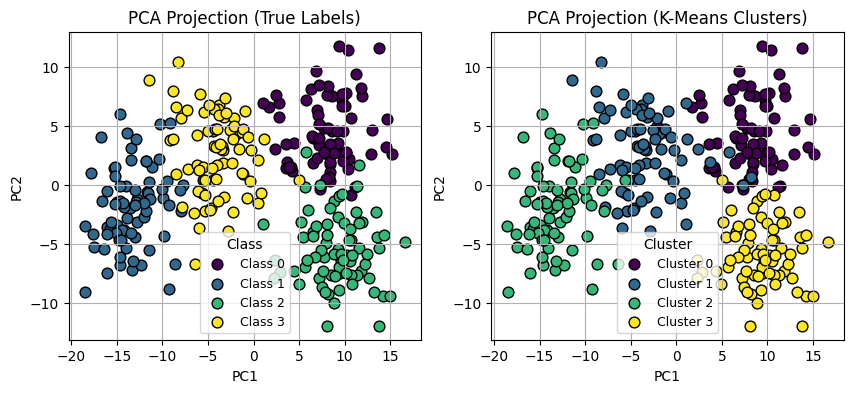

In [ ]:
# Load data from PADL-Q2.csv
data = np.loadtxt((DATA_DIRECTORY + 'PADL-Q2.csv'), delimiter=',', skiprows=1)

# Extract into features and labels
X = data[:, :-1]
Y = data[:, -1]

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define number of clusters
num_clusters = len(np.unique(Y))

# K-means on original data
kmeans = KMeans(n_clusters=num_clusters)
Y_kmeans = kmeans.fit_predict(X_scaled)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Colour map
cmap = plt.get_cmap('viridis', num_clusters)

# Create figure
plt.figure(figsize=(10,4))

# Plot 1: PCA with true labels
plt.subplot(1, 2, 1)
for i, label in enumerate(np.unique(Y)):
    color = cmap(i)
    plt.scatter(X_pca[Y == label, 0], X_pca[Y == label, 1],
                label=f'Class {int(label)}', c=[color], edgecolor='k', s=60)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (True Labels)')
plt.legend(title='Class', fontsize=9)
plt.grid(True)

# Plot 2: PCA with K-means clusters
plt.subplot(1, 2, 2)
for i in range(num_clusters):
    color = cmap(i)
    plt.scatter(X_pca[Y_kmeans == i, 0], X_pca[Y_kmeans == i, 1],
                label=f'Cluster {i}', c=[color], edgecolor='k', s=60, marker='o')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (K-Means Clusters)')
plt.legend(title='Cluster', fontsize=9)
plt.grid(True)

### B

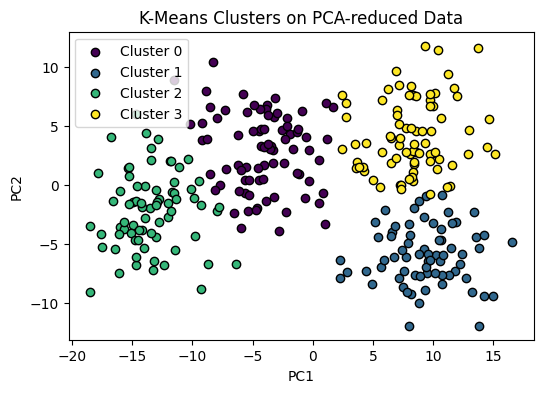

In [ ]:
# Apply K-means to PCA data
kmeans_pca = KMeans(n_clusters=num_clusters)
Y_kmeans_pca = kmeans_pca.fit_predict(X_pca)

# Plot predictions from kmeans after PCA
plt.figure(figsize=(6, 4))

for cluster in range(num_clusters):
    plt.scatter(X_pca[Y_kmeans_pca == cluster, 0], X_pca[Y_kmeans_pca == cluster, 1],
                label=f"Cluster {cluster}",c=[cmap(cluster)], edgecolor="k")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters on PCA-reduced Data")
plt.legend()
plt.show()

### C

In [ ]:
def clustering_accuracy(y_true, y_pred):
    # Build confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Solve the assignment problem (Hungarian algorithm)
    row_ind, col_ind = linear_sum_assignment(-cm)
    # Map predicted labels to best-matching true labels
    optimal_mapping = {old: new for old, new in zip(col_ind, row_ind)}
    mapped_preds = np.vectorize(optimal_mapping.get)(y_pred)
    # Return accuracy
    return accuracy_score(y_true, mapped_preds)

acc_full = clustering_accuracy(Y, Y_kmeans)
acc_pca = clustering_accuracy(Y, Y_kmeans_pca)
pca_variance = np.sum(pca.explained_variance_ratio_) * 100

print(f"Accuracy with all five features: {acc_full:.4f}")
print(f"Accuracy with PCA-reduced features: {acc_pca:.4f}")
print(f"Percentage of variance explained by PCA: {pca_variance:.2f}%")
print(f"Accuracy drop: {acc_full - acc_pca:.2%}")

Accuracy with all five features: 0.9467
Accuracy with PCA-reduced features: 0.9400
Percentage of variance explained by PCA: 77.43%
Accuracy drop: 0.67%


## Q3

### A

In [ ]:
# Load data from PADL-Q3.txt
with open((DATA_DIRECTORY + 'PADL-Q3.txt'), 'r') as f:
    sentences = [line.strip().split() for line in f]

# Train a Skip-gram Word2Vec model
skip_gram_model = Word2Vec(sentences=sentences, min_count=1 ,sg=1)
word_embeddings = skip_gram_model.wv

# Cosine similarities betweeen node 5 and nodes 21 - 30
print("Similarities with node 5:")
for i in range(21, 31):
    try:
        sim = word_embeddings.similarity("5", str(i))
        print(f"Node 5 <-> Node {i}: {sim:.4f}")
    except KeyError:
        print(f"Node {i} not in vocabulary.")


Similarities with node 5:
Node 5 <-> Node 21: 0.1448
Node 5 <-> Node 22: 0.1244
Node 5 <-> Node 23: 0.3228
Node 5 <-> Node 24: 0.2844
Node 5 <-> Node 25: 0.1413
Node 5 <-> Node 26: 0.1850
Node 5 <-> Node 27: 0.2656
Node 5 <-> Node 28: 0.2507
Node 5 <-> Node 29: 0.1785
Node 5 <-> Node 30: 0.1902


### B

In [ ]:
# Get all node IDs from the model
node_ids = skip_gram_model.wv.index_to_key

# Build similarity matrix
output_lines = []
for node in node_ids:
    similarities = []
    for other in node_ids:
        if node != other:
            sim = word_embeddings.similarity(node, other)
            similarities.append((other, sim))

    # Sort by similarity descending
    similarities.sort(key=lambda x: x[1], reverse=True)
    sorted_node_ids = [node_id for node_id, _ in similarities]

    # Append as space-separated line
    output_lines.append(" ".join(sorted_node_ids))

# Save to result file
result_path = PROJECT_DIRECTORY + "PADL-Q3-result.txt"
with open(result_path, "w") as f:
    f.write("\n".join(output_lines))

print(f"Result saved to {result_path}")


Result saved to /content/drive/MyDrive/padl_ws/PADL-Q3-result.txt


## Q4

### A

For this problem I have chosen to use an MLP with 3 hidden layers all with skip connections


### B

#### NHANES

In [ ]:
# NHANES data -----------------------------------------------
nhanes_data = np.genfromtxt(DATA_DIRECTORY + 'nhanes_body_measurements.csv',
                            delimiter=',', skip_header=1)

# Split features and target
X_nhanes = nhanes_data[:, :-1]  # All columns except last (input features)
y_nhanes = nhanes_data[:, -1]   # Last column (waist circumference)

hip = X_nhanes[:, 0]
height = X_nhanes[:, 1]
weight = X_nhanes[:, 2]
gender = X_nhanes[:, 3]

height_m = height / 1000.0  # or adjust if height unit differs

bmi = weight / (height_m ** 2)
hip_to_height = hip / height_m
log_hip = np.log(hip + 1)
log_height = np.log(height_m + 1)
log_weight = np.log(weight + 1)
sqrt_weight = np.sqrt(weight)
sqrt_height = np.sqrt(height_m)
sqrt_hip = np.sqrt(hip)
inv_hip = 1 / (hip + 1e-6)
inv_height = 1 / (height_m + 1e-6)
inv_weight = 1 / (weight + 1e-6)

# Or you can skip this if it doesn't make sense.

engineered = np.stack([
    bmi,
    hip_to_height,
    log_hip,
    log_height,
    log_weight,
    sqrt_weight,
    sqrt_height,
    sqrt_hip,
    inv_hip,
    inv_height,
    inv_weight,
], axis=1)

# Split into train, val, test
X_train_val_n, X_test_n, y_train_val_n, y_test_n = train_test_split(
    X_nhanes, y_nhanes, test_size=0.2)

X_train_n, X_val_n, y_train_n, y_val_n = train_test_split(
    X_train_val_n, y_train_val_n, test_size=0.1)

scaler = StandardScaler()
scaler.fit(X_train_n)
X_train_n = scaler.transform(X_train_n)
X_val_n = scaler.transform(X_val_n)
X_test_n = scaler.transform(X_test_n)

X_train_tensor_n = torch.tensor(X_train_n, dtype=torch.float32)
X_val_tensor_n = torch.tensor(X_val_n, dtype=torch.float32)
X_test_tensor_n = torch.tensor(X_test_n, dtype=torch.float32)

y_train_tensor_n = torch.tensor(y_train_n.reshape(-1, 1), dtype=torch.float32)
y_val_tensor_n = torch.tensor(y_val_n.reshape(-1, 1), dtype=torch.float32)
y_test_tensor_n = torch.tensor(y_test_n.reshape(-1, 1), dtype=torch.float32)

#### Data

In [34]:
# Funcs and variables
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def augment_gaussian_noise(X, n_augment=1, noise_std=0.01):
    augmented = []
    for _ in range(n_augment):
        noise = np.random.normal(loc=0, scale=noise_std, size=X.shape)
        X_noisy = X * (1 + noise)  # relative noise
        augmented.append(X_noisy)
    return np.vstack(augmented)

# Load data --------------------------------------------------------------------
data = np.genfromtxt((DATA_DIRECTORY + 'body_measurements.csv'),
                     delimiter=',', skip_header=1)
print(data.shape)

# Filter bad data samples ------------------------------------------------------
# Filter out NaN rows
valid_rows = ~np.isnan(data).any(axis=1)
data_filtered = data[valid_rows]

# Filter out rows with outlier waist values using the IQR method
waist = data_filtered[:, -1]
Q1 = np.percentile(waist, 25)
Q3 = np.percentile(waist, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

inlier_mask = (waist >= lower_bound) & (waist <= upper_bound)
data_clean = data_filtered[inlier_mask]

# Filter out rows with outlier features using isolation forest
iso = IsolationForest(contamination=0.01)
outliers = iso.fit_predict(data_clean[:, 1:-1])

# Keep only inliers
mask = outliers == 1
data_clean = data_clean[mask]

print(data_clean.shape)

# Extract original features ----------------------------------------------------
gender = data_clean[:, 0]
gender = np.where(gender == 0, -1, 1)

chest = data_clean[:, 1]
hip = data_clean[:, 2]
height = data_clean[:, 3]
weight = data_clean[:, 4]

original = np.stack([chest, hip, height, weight], axis=1)

waist = data_clean[:, -1]

# Feature Engineering ----------------------------------------------------------
height_m = height / 1000.0  # convert mm to meters

bmi = weight / (height_m ** 2)
chest_to_height = chest / height_m
hip_to_height = hip / height_m
hip_to_chest = hip / chest
waist_proxy = (chest + hip) / 2
sum_chest_hip_to_height = (chest + hip) / height_m
chest_sq_div_hip = (chest ** 2) / hip
log_chest = np.log(chest + 1)
log_hip = np.log(hip + 1)
log_height = np.log(height_m + 1)
log_weight = np.log(weight + 1)
sqrt_weight = np.sqrt(weight)
sqrt_height = np.sqrt(height_m)
sqrt_chest = np.sqrt(chest)
sqrt_hip = np.sqrt(hip)
abs_hip_chest_norm = np.abs(hip - chest) / height_m
chest_hip_over_weight = (chest + hip) / weight
inv_chest = 1 / (chest + 1e-6)
inv_hip = 1 / (hip + 1e-6)
weight_to_chest = weight / chest
inv_height = 1 / (height_m + 1e-6)
inv_hip = 1 / (hip + 1e-6)
inv_weight = 1 / (weight + 1e-6)
inv_chest = 1 / (chest + 1e-6)
chest_to_height_inv = 1 / (chest_to_height + 1e-6)
hip_to_height_inv = 1 / (hip_to_height + 1e-6)

engineered = np.stack([
    bmi,
    chest_to_height,
    hip_to_height,
    hip_to_chest,
    waist_proxy,
    sum_chest_hip_to_height,
    chest_sq_div_hip,
    log_chest,
    log_hip,
    sqrt_weight,
    abs_hip_chest_norm,
    chest_hip_over_weight,
    inv_chest,
    inv_hip,
    weight_to_chest,
    inv_height,
    inv_hip,
    inv_weight,
    inv_chest,
    chest_to_height_inv,
    hip_to_height_inv,
    log_height,
    log_weight,
    sqrt_height,
    sqrt_chest,
    sqrt_hip
], axis=1)

# Concatenate with original features
X_engineered = np.concatenate([original,  engineered], axis=1)

X = np.stack([hip, height, weight, gender], axis=1)

print(X_engineered.shape)

# Feature selection ------------------------------------------------------------
# Use RFE for feature selection
rfe = RFE(LinearRegression(), n_features_to_select=15)

X_selected = rfe.fit_transform(X_engineered, waist)
# Data splits ------------------------------------------------------------------
# Final input feature tensor (excluding gender)
# X_train_val, X_test, y_train_val, y_test, gender_train_val, gender_test = train_test_split(
#     X_engineered, waist, gender, test_size=0.20
# )

# X_train, X_val, y_train, y_val, gender_train, gender_val = train_test_split(
#     X_train_val, y_train_val, gender_train_val, test_size=0.10
# )

X_train, X_test, y_train, y_test = train_test_split(
    X, waist, test_size=0.20
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.10
)

print(f'Train: {X_train.shape}')
print(f'Val: {X_val.shape}')
print(f'Test: {X_test.shape}')

# Standardize numeric features -------------------------------------------------
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

gender_train = gender_train.reshape(-1, 1)
gender_val = gender_val.reshape(-1, 1)
gender_test = gender_test.reshape(-1, 1)

# Combine gender back ----------------------------------------------------------
X_train_final = np.hstack([gender_train, X_train_scaled])
X_val_final = np.hstack([gender_val, X_val_scaled])
X_test_final = np.hstack([gender_test, X_test_scaled])

# Augment data -----------------------------------------------------------------

data_augmented = np.vstack([(X_train_final), augment_gaussian_noise(X_train_final, n_augment=2, noise_std=0.02)])

print(data_augmented.shape)

# Convert to PyTorch tensors ---------------------------------------------------
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)


(1800, 6)
(1736, 6)
(1736, 30)
Train: (1249, 4)
Val: (139, 4)
Test: (348, 4)
(3747, 5)


#### Model

In [35]:
class ResidualBlock(nn.Module):
    def __init__(self, size, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(size, size),
            nn.BatchNorm1d(size),
            nn.LayerNorm(size),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return x + self.block(x)

class WaistPredictor(nn.Module):
    def __init__(self, input_size, dropout=0.1):
        super().__init__()
        hidden_size = 64

        self.attention = nn.Sequential(
            nn.Linear(input_size, input_size),
            nn.Sigmoid()
        )

        self.input_layer = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.res_block1 = ResidualBlock(hidden_size, dropout=dropout)
        self.res_block2 = ResidualBlock(hidden_size, dropout=dropout)
        self.res_block3 = ResidualBlock(hidden_size, dropout=dropout)

        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, x):
        attention_weights = self.attention(x)
        x = x * attention_weights
        x = self.input_layer(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        x = self.res_block3(x)
        x = self.output_layer(x)
        return x


# Define model
waist_predictor = WaistPredictor(input_size=X_train_tensor.shape[1]).to(device)


#### Pre-Training

In [36]:
loss_function = nn.L1Loss()

optimiser = optim.AdamW(waist_predictor.parameters(), lr = 1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.1, patience=10, min_lr=1e-6)

epochs = 500
batch_size = 128

train_dataset = TensorDataset(X_train_tensor_n, y_train_tensor_n)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataset = TensorDataset(X_val_tensor_n, y_val_tensor_n)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 100
lr_changes = []

# Training loop
waist_predictor.train()
for epoch in range(epochs):
    total_train_loss = 0.0
    total_val_loss = 0.0
    waist_predictor.train()
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimiser.zero_grad()
        predictions = waist_predictor(batch_X)
        loss = loss_function(predictions, batch_y)
        loss.backward()
        optimiser.step()
        total_train_loss += loss.item() * batch_X.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # Validation
    waist_predictor.eval()
    total_val_loss = 0.0
    with torch.no_grad():
      for batch_X, batch_y in val_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        val_preds = waist_predictor(batch_X)
        val_loss = loss_function(val_preds, batch_y).item()
        total_val_loss += val_loss * batch_X.size(0)

    avg_val_loss = total_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)

    current_lr = scheduler.optimizer.param_groups[0]['lr']
    lr_changes.append(current_lr)

    if (epoch+1)%10 == 0:
        print(f"Epoch {epoch+1}, Train MAE: {avg_train_loss:.2f}, Train MAE: Val MAE: {avg_val_loss:.2f}, lr {current_lr}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(waist_predictor.state_dict(), MODEL_DIRECTORY + 'waist_predictor_NHANES.pth')


Epoch 10, Train MAE: 856.71, Train MAE: Val MAE: 827.97, lr 0.001
Epoch 20, Train MAE: 552.84, Train MAE: Val MAE: 516.77, lr 0.001
Epoch 30, Train MAE: 129.75, Train MAE: Val MAE: 103.95, lr 0.001
Epoch 40, Train MAE: 57.51, Train MAE: Val MAE: 50.45, lr 0.001
Epoch 50, Train MAE: 55.29, Train MAE: Val MAE: 48.55, lr 0.001
Epoch 60, Train MAE: 54.78, Train MAE: Val MAE: 48.53, lr 0.0001
Epoch 70, Train MAE: 53.78, Train MAE: Val MAE: 48.13, lr 0.0001
Epoch 80, Train MAE: 54.41, Train MAE: Val MAE: 48.21, lr 1e-05
Epoch 90, Train MAE: 53.80, Train MAE: Val MAE: 48.10, lr 1.0000000000000002e-06
Epoch 100, Train MAE: 54.39, Train MAE: Val MAE: 48.24, lr 1.0000000000000002e-06
Epoch 110, Train MAE: 53.71, Train MAE: Val MAE: 48.19, lr 1.0000000000000002e-06
Epoch 120, Train MAE: 54.36, Train MAE: Val MAE: 48.07, lr 1.0000000000000002e-06
Epoch 130, Train MAE: 54.06, Train MAE: Val MAE: 48.07, lr 1.0000000000000002e-06
Epoch 140, Train MAE: 53.81, Train MAE: Val MAE: 48.19, lr 1.0000000000

KeyboardInterrupt: 

#### Fine tuning

In [38]:
waist_predictor = WaistPredictor(input_size=X_train_tensor.shape[1]).to(device)
waist_predictor.load_state_dict(torch.load(MODEL_DIRECTORY + 'waist_predictor_NHANES.pth'))

for param in waist_predictor.attention.parameters():
    param.requires_grad = False

for param in waist_predictor.input_layer.parameters():
    param.requires_grad = False

for param in waist_predictor.res_block1.parameters():
    param.requires_grad = False

for param in waist_predictor.res_block2.parameters():
    param.requires_grad = False

for param in waist_predictor.res_block3.parameters():
    param.requires_grad = True

for param in waist_predictor.output_layer.parameters():
    param.requires_grad = True

loss_function = nn.L1Loss()

optimiser = optim.AdamW(waist_predictor.parameters(), lr = 1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.1, patience=10, min_lr=1e-6)

epochs = 500
batch_size = 128

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 100
lr_changes = []

# Training loop
waist_predictor.train()
for epoch in range(epochs):
    total_train_loss = 0.0
    total_val_loss = 0.0
    waist_predictor.train()
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimiser.zero_grad()
        predictions = waist_predictor(batch_X)
        loss = loss_function(predictions, batch_y)
        loss.backward()
        optimiser.step()
        total_train_loss += loss.item() * batch_X.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # Validation
    waist_predictor.eval()
    total_val_loss = 0.0
    with torch.no_grad():
      for batch_X, batch_y in val_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        val_preds = waist_predictor(batch_X)
        val_loss = loss_function(val_preds, batch_y).item()
        total_val_loss += val_loss * batch_X.size(0)

    avg_val_loss = total_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)

    current_lr = scheduler.optimizer.param_groups[0]['lr']
    lr_changes.append(current_lr)

    if (epoch+1)%10 == 0:
        print(f"Epoch {epoch+1}, Train MAE: {avg_train_loss:.2f}, Train MAE: Val MAE: {avg_val_loss:.2f}, lr {current_lr}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(waist_predictor.state_dict(), MODEL_DIRECTORY + 'waist_predictor_temp.pth')


Epoch 10, Train MAE: 126.38, Train MAE: Val MAE: 111.45, lr 0.0001
Epoch 20, Train MAE: 117.23, Train MAE: Val MAE: 101.88, lr 0.0001
Epoch 30, Train MAE: 108.85, Train MAE: Val MAE: 95.90, lr 0.0001
Epoch 40, Train MAE: 101.37, Train MAE: Val MAE: 86.34, lr 0.0001
Epoch 50, Train MAE: 90.63, Train MAE: Val MAE: 79.61, lr 0.0001
Epoch 60, Train MAE: 85.36, Train MAE: Val MAE: 70.54, lr 0.0001
Epoch 70, Train MAE: 75.87, Train MAE: Val MAE: 64.36, lr 0.0001
Epoch 80, Train MAE: 69.90, Train MAE: Val MAE: 59.40, lr 0.0001
Epoch 90, Train MAE: 64.68, Train MAE: Val MAE: 53.71, lr 0.0001
Epoch 100, Train MAE: 57.61, Train MAE: Val MAE: 49.19, lr 0.0001
Epoch 110, Train MAE: 54.40, Train MAE: Val MAE: 45.71, lr 0.0001
Epoch 120, Train MAE: 51.20, Train MAE: Val MAE: 42.71, lr 0.0001
Epoch 130, Train MAE: 48.31, Train MAE: Val MAE: 39.75, lr 0.0001
Epoch 140, Train MAE: 46.32, Train MAE: Val MAE: 38.70, lr 0.0001
Epoch 150, Train MAE: 45.22, Train MAE: Val MAE: 37.28, lr 0.0001
Epoch 160, Tr

#### Testing

MAE on the test set: 35.01
Model size: 70854 bytes
Model size: 0.06757164001464844 MB


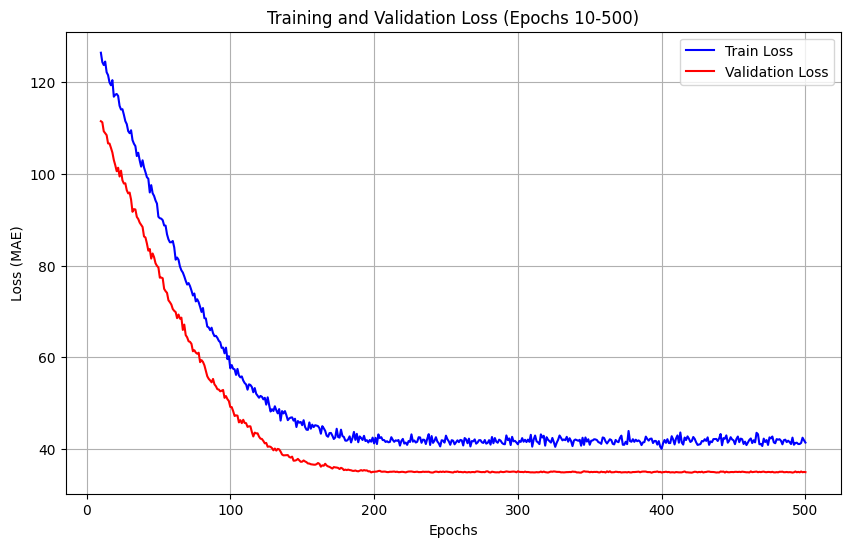

In [39]:
waist_predictor.load_state_dict(torch.load(MODEL_DIRECTORY + 'waist_predictor_temp.pth'))

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Switch to evaluation mode
waist_predictor.eval()
total_test_loss = 0.0
with torch.no_grad():
  for batch_X, batch_y in test_loader:
    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
    y_test_pred = waist_predictor(batch_X)
    test_loss = loss_function(y_test_pred, batch_y).item()
    total_test_loss += test_loss * batch_X.size(0)

avg_test_loss = total_test_loss / len(test_loader.dataset)
print(f"MAE on the test set: {avg_test_loss:.2f}")

file_size = os.path.getsize(MODEL_DIRECTORY + 'waist_predictor_temp.pth')
print(f"Model size: {file_size} bytes")
print(f"Model size: {file_size / (1024**2)} MB") # in MB

# Plot training and validation loss from epoch 100 to 1000
start_epoch = 10
end_epoch = len(train_losses)

plt.figure(figsize=(10, 6))
plt.plot(range(start_epoch, end_epoch + 1), train_losses[start_epoch - 1:end_epoch], label="Train Loss", color='blue')
plt.plot(range(start_epoch, end_epoch + 1), val_losses[start_epoch - 1:end_epoch], label="Validation Loss", color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss (MAE)')
plt.title(f'Training and Validation Loss (Epochs {start_epoch}-{end_epoch})')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# torch.save(waist_predictor.state_dict(), MODEL_DIRECTORY + "/waist_predictor.pth")

## Q5

### A

Architecture:
I have implemented a slighlty adjusted version of EfficientNetB0, as it remains one of the best convolution based architectures for image classification, while also being small and efficient. The final classification head has been modified in to

Justification:

EfficientNet super good




### B

#### Data

In [70]:
DATASET_PATH = DATA_DIRECTORY + 'garment_images'
LABELS_CSV = DATA_DIRECTORY + 'garment_images/train_labels.csv'
num_workers = 4
batch_size = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

base_transform = transforms.Compose([
    transforms.Resize(256),
])

final_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

augmented_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    final_transform,
])

class GarmentImageDataset(Dataset):
    def __init__(self, root_dir, labels_csv, transform=None):
        self.root_dir = root_dir
        self.labels_df = pd.read_csv(labels_csv)
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        filename = self.labels_df.iloc[idx, 0]
        label = int(self.labels_df.iloc[idx, 1])

        img_path = os.path.join(self.root_dir, str(label), filename)

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

class AugmentedDataset(Dataset):
    def __init__(self, subset, original_transform, augmented_transform, n_augmentations=0):
        self.subset = subset
        self.original_transform = original_transform
        self.augmented_transform = augmented_transform
        self.n_augmentations = n_augmentations
        self.expanded_indices = []
        for idx in range(len(subset)):
            self.expanded_indices.append((idx, 'original'))
            for _ in range(n_augmentations):
                self.expanded_indices.append((idx, 'augmented'))

    def __len__(self):
        return len(self.expanded_indices)

    def __getitem__(self, idx):
        base_idx, mode = self.expanded_indices[idx]
        image, label = self.subset[base_idx]

        if mode == 'original':
            image = self.original_transform(image)
        else:
            image = self.augmented_transform(image)

        return image, label


# Original dataset without transform
base_dataset = GarmentImageDataset(DATASET_PATH, LABELS_CSV)

print(len(base_dataset))

# Load labels
labels_df = pd.read_csv(LABELS_CSV)
labels = labels_df.iloc[:, 1].tolist()  # assuming second column is labels
labels = np.array(labels)

# Define the stratified splitter
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.3)
for train_index, temp_index in sss1.split(np.zeros(len(labels)), labels):
    pass

temp_labels = labels[temp_index]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.66)
for val_index, test_index in sss2.split(np.zeros(len(temp_labels)), temp_labels):
    pass

# Get actual indices for subsets
val_index = np.array(temp_index)[val_index]
test_index = np.array(temp_index)[test_index]

# Create subsets
train_subset = torch.utils.data.Subset(base_dataset, train_index)
val_subset = torch.utils.data.Subset(base_dataset, val_index)
test_subset = torch.utils.data.Subset(base_dataset, test_index)

# Wrap train subset with a transform
train_dataset = AugmentedDataset(train_subset, final_transform, augmented_transform, n_augmentations=3)
val_dataset = AugmentedDataset(val_subset, final_transform, final_transform, n_augmentations=0)
test_dataset = AugmentedDataset(test_subset, final_transform, final_transform, n_augmentations=0)

# Create dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

# Get labels for train subset only
train_labels = labels[train_index]
label_counts = Counter(train_labels)
total_samples = len(train_labels)
num_classes = len(label_counts)

class_weights = []
for label in sorted(label_counts.keys()):
    count = label_counts[label]
    weight = total_samples / (num_classes * count) if count > 0 else 0.0
    class_weights.append(weight)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print(class_weights_tensor)


cuda
2626
Train size: 7352
Validation size: 267
Test size: 521
tensor([0.8545, 0.9648, 1.2606])


#### Model

In [71]:
# Instantiate model
fashion_classifier = models.efficientnet_b0(weights=None)
fashion_classifier.classifier = nn.Sequential(
    nn.Linear(fashion_classifier.classifier[1].in_features, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, 3)  # output 3 classes
)

fashion_classifier.to(device)
print()

#### Training

In [72]:
# Hyperparameters
learning_rate = 3e-4
epochs = 30
weight_decay = 3e-3
best_val_loss = float('inf')

criterion = nn.CrossEntropyLoss(class_weights_tensor.to(device))
optimiser = optim.AdamW(fashion_classifier.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=5, min_lr=1e-6)

# Lists to store loss and accuracy values for plotting
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training loop
fashion_classifier.train()
correct, total = 0, 0

# Training and validation loop
for epoch in range(epochs):

    # Train the model
    fashion_classifier.train()
    train_correct, train_total = 0, 0
    running_loss = 0.0
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)

        optimiser.zero_grad()

        outputs = fashion_classifier(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimiser.step()

        running_loss += loss.item()
        train_total += labels.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()

    train_accuracy = 100 * train_correct / train_total
    avg_train_loss = running_loss / len(train_dataloader)

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%", end='')

    # Validation Loop
    fashion_classifier.eval()
    val_correct, val_total = 0, 0
    val_loss_total = 0.0
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = fashion_classifier(images)
            loss = criterion(outputs, labels)
            val_loss_total += loss.item()

            val_total += labels.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total
    avg_val_loss = val_loss_total / len(val_dataloader)

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    scheduler.step(avg_val_loss)

    print(f" - Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(fashion_classifier.state_dict(), MODEL_DIRECTORY + 'fashion_classifier_temp.pth')
        print("Best model saved!")

KeyboardInterrupt: 

#### Eval

Test Loss: 0.1663, Test Accuracy: 95.20%
Model size: 17655620 bytes
Model size: 16.837711334228516 MB


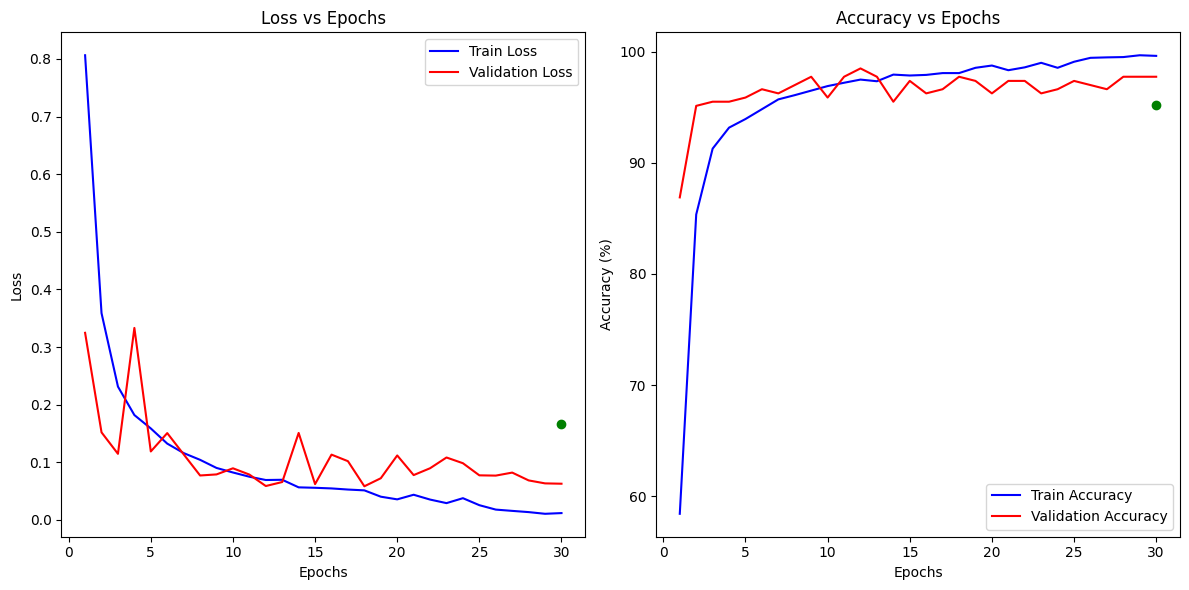

In [65]:
fashion_classifier.load_state_dict(torch.load(MODEL_DIRECTORY + 'fashion_classifier_temp.pth'))
fashion_classifier.eval()
test_correct, test_total = 0, 0
test_loss = 0.0
with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)

        outputs = fashion_classifier(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_accuracy = 100 * test_correct / test_total
average_test_loss = test_loss / len(test_dataloader)


print(f"Test Loss: {average_test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

file_size = os.path.getsize(MODEL_DIRECTORY + 'fashion_classifier_temp.pth')
print(f"Model size: {file_size} bytes")
print(f"Model size: {file_size / (1024**2)} MB") # in MB

# Plot Loss vs Epochs
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss", color="blue")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss", color="red")
plt.plot(len(train_losses), average_test_loss, 'go')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()

# Plot Accuracy vs Epochs
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label="Train Accuracy", color="blue")
plt.plot(range(1, len(val_losses) + 1), val_accuracies, label="Validation Accuracy", color="red")
plt.plot(len(train_accuracies), test_accuracy, 'go')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Epochs")
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()

In [ ]:
# torch.save(fashion_classifier.state_dict(), MODEL_DIRECTORY + "/fashion_classifier.pth")

## Q6

### Code

#### Data

In [41]:
dataset_path = DATA_DIRECTORY + "/face_images"

class FaceDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform or transforms.Compose([
            transforms.ToTensor(),
        ])
        self.image_paths = [os.path.join(data_dir, fname) for fname in os.listdir(data_dir)]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('L')  # Convert to grayscale
        if self.transform:
            image = self.transform(image)
        return image

# Define split sizes
total_size = len(os.listdir(dataset_path))
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

# Load the full dataset
full_dataset = FaceDataset(data_dir=dataset_path)

# Split into train, validation, and test
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

#### Autoencoder and Functions

In [40]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.convolutions = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),  # 192x160 → 96x80
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # 96x80 → 48x40
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),  # 48x40 → 24x20
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),  # 24x20 → 12x10
            nn.ReLU(),
        )
        self.fc = nn.Linear(256 * 12 * 10, 32)

    def forward(self, x):
        x = self.convolutions(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(32, 256 * 12 * 10)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 12x10 → 24x20
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 24x20 → 48x40
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 48x40 → 96x80
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),  # 96x80 → 192x160
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(x.size(0), 256, 12, 10)
        return self.deconv(x)

def ssim_score(image1, image2):
    image1 = image1.squeeze().detach().cpu().numpy()
    image2 = image2.squeeze().detach().cpu().numpy()
    return ssim(image1, image2, data_range=1.0)

def plot_images(original, reconstructed):
    # Ensure the image is in the correct range [0, 1]
    reconstructed = torch.clamp(reconstructed, 0, 1)

    # Convert to NumPy and squeeze batch dimension
    original = original.squeeze().cpu().detach().numpy()
    reconstructed = reconstructed.squeeze().cpu().detach().numpy()

    # Plotting the original and reconstructed images
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(reconstructed, cmap='gray')
    axes[1].set_title('Reconstructed Image')
    axes[1].axis('off')

    plt.show()

# Create the Encoder and Decoder
encoder = Encoder()
decoder = Decoder()

#### Training

In [42]:
# Define hyperparameters
learning_rate = 1e-3
batch_size = 64
epochs = 30

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

optimiser = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=learning_rate)

loss_fn = nn.MSELoss()

# Some training variables
train_losses = []
val_losses = []
train_ssims = []
val_ssims = []
best_val_ssim = 0.0
temp_model_path = MODEL_DIRECTORY + "autoencoder_temp.pth"

# Training loop
for epoch in range(epochs):
    encoder.train()
    decoder.train()

    running_loss = 0.0
    running_ssim = 0.0

    # Training loop
    for i, images in enumerate(train_loader):
        optimiser.zero_grad()
        latents = encoder(images)
        reconstructed_images = decoder(latents)

        loss = loss_fn(reconstructed_images, images)
        ssim_value = ssim_score(reconstructed_images, images)

        loss.backward()
        optimiser.step()

        running_loss += loss.item()
        running_ssim += ssim_value

    avg_loss = running_loss / len(train_loader)
    avg_ssim = running_ssim / len(train_loader)

    # Print training statistics
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, SSIM: {avg_ssim:.4f}", end='')

    # Validation
    encoder.eval()
    decoder.eval()

    running_val_loss = 0.0
    running_ssim_val = 0.0

    with torch.no_grad():
        for images in val_loader:
            latents = encoder(images)
            reconstructed_images = decoder(latents)

            val_loss = loss_fn(reconstructed_images, images)
            running_val_loss += val_loss.item()

            ssim_value = ssim_score(reconstructed_images, images)
            running_ssim_val += ssim_value

    avg_val_loss = running_val_loss / len(val_loader)
    avg_ssim_val = running_ssim_val / len(val_loader)

    # Print validation statistics
    print(f", Validation Loss: {avg_val_loss:.4f}, SSIM: {avg_ssim_val:.4f}")

    # Save best model based on SSIM
    if avg_ssim_val > best_val_ssim:
      best_val_ssim = avg_ssim_val
      torch.save({
          'encoder_state_dict': encoder.state_dict(),
          'decoder_state_dict': decoder.state_dict(),
      }, temp_model_path)
      print("Best model saved!")

    # Append losses and ssims for visualisation
    train_losses.append(avg_loss)
    val_losses.append(avg_val_loss)
    train_ssims.append(avg_ssim)
    val_ssims.append(avg_ssim_val)

Epoch [1/20], Loss: 0.0609, SSIM: 0.2540, Validation Loss: 0.0335, SSIM: 0.6348
Best model saved!
Epoch [2/20], Loss: 0.0272, SSIM: 0.6890, Validation Loss: 0.0252, SSIM: 0.7127
Best model saved!
Epoch [3/20], Loss: 0.0225, SSIM: 0.7346, Validation Loss: 0.0220, SSIM: 0.7471
Best model saved!
Epoch [4/20], Loss: 0.0201, SSIM: 0.7672, Validation Loss: 0.0201, SSIM: 0.7748
Best model saved!
Epoch [5/20], Loss: 0.0181, SSIM: 0.7887, Validation Loss: 0.0173, SSIM: 0.7997
Best model saved!
Epoch [6/20], Loss: 0.0133, SSIM: 0.8343, Validation Loss: 0.0117, SSIM: 0.8531
Best model saved!
Epoch [7/20], Loss: 0.0107, SSIM: 0.8626, Validation Loss: 0.0102, SSIM: 0.8675
Best model saved!
Epoch [8/20], Loss: 0.0093, SSIM: 0.8754, Validation Loss: 0.0092, SSIM: 0.8805
Best model saved!
Epoch [9/20], Loss: 0.0083, SSIM: 0.8870, Validation Loss: 0.0083, SSIM: 0.8899
Best model saved!
Epoch [10/20], Loss: 0.0075, SSIM: 0.8963, Validation Loss: 0.0077, SSIM: 0.8976
Best model saved!
Epoch [11/20], Loss

#### Testing

Test Loss: 0.003856059443205595, SSIM: 0.9450


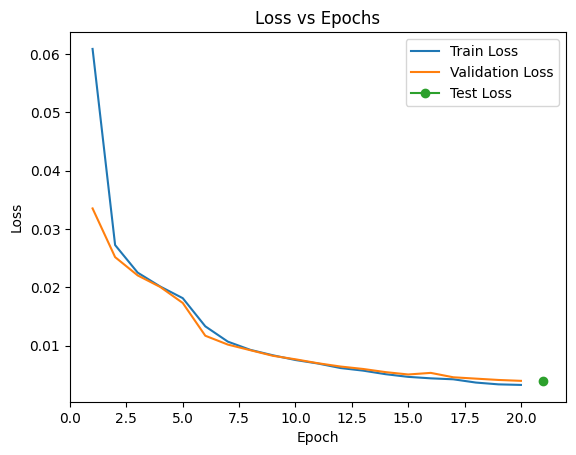

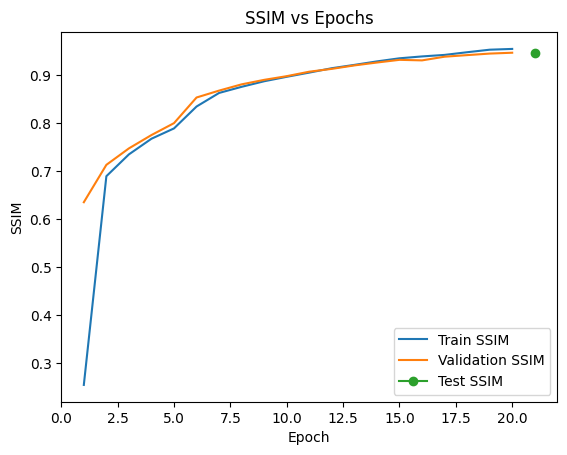

In [43]:
encoder.load_state_dict(torch.load(temp_model_path)['encoder_state_dict'])
decoder.load_state_dict(torch.load(temp_model_path)['decoder_state_dict'])
encoder.eval()
decoder.eval()
running_ssim_test = 0.0
running_test_loss = 0.0
with torch.no_grad():
  for images in test_loader:
    latents = encoder(images)
    reconstructed_images = decoder(latents)

    test_loss = loss_fn(reconstructed_images, images)
    running_test_loss += test_loss.item()

    ssim_value = ssim_score(reconstructed_images, images)
    running_ssim_test += ssim_value

avg_ssim_test = running_ssim_test / len(test_loader)
avg_test_loss = running_test_loss / len(test_loader)

# Print testing statistics
print(f"Test Loss: {avg_test_loss}, SSIM: {avg_ssim_test:.4f}")

# ——— Plot Loss vs Epochs ———
plt.figure()
plt.plot(range(1, len(train_losses)  + 1), train_losses,    label="Train Loss")
plt.plot(range(1, len(val_losses)    + 1), val_losses,      label="Validation Loss")
plt.plot(len(train_losses) + 1, avg_test_loss,              marker='o', label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.show()

# ——— Plot SSIM vs Epochs ———
plt.figure()
plt.plot(range(1, len(train_ssims)   + 1), train_ssims,     label="Train SSIM")
plt.plot(range(1, len(val_ssims)     + 1), val_ssims,       label="Validation SSIM")
plt.plot(len(train_ssims) + 1, avg_ssim_test,               marker='o', label="Test SSIM")
plt.xlabel("Epoch")
plt.ylabel("SSIM")
plt.title("SSIM vs Epochs")
plt.legend()
plt.show()

In [44]:
autoencoder_size = os.path.getsize(temp_model_path) / (1024 * 1024)
print(f"Total size: {autoencoder_size:.2f} MiB")

Total size: 12.88 MiB


In [ ]:
# torch.save({'encoder_state_dict': encoder.state_dict(), 'decoder_state_dict': decoder.state_dict(),}, MODEL_DIRECTORY + 'autoencoder.pth')

### A

#### Architecture
The autoencoder seen above was designed to take the 192x168 image and compress to a latent representation of 32D and then decompress back to the original image. The architecture is as follows:

Encoder:
* 4 convolutional layers with kernel size 4, stride 2, and padding 1

* ReLU activation after each convolution for non-linearity

* Flatten layer followed by a fully connected layer

* Linear(256×12×10, 32) → compresses to 32D latent vector

Decoder:
* Fully connected layer (Linear(32, 256×12×10)) to expand latent vector:

* 4 transposed convolutional layers that mirror the encoder

* ReLU activations in all hidden layers

* Final Sigmoid activation to normalize output to (0, 1) range

#### Justifications
Strided convolutions are used to encode as they efficiently reduce spatial resolution while learning abstract features, avoiding pooling layers. Pooling layers are avoided as they do not have learnable downsampling and is non-invertible. Transposed convolutions are used to reconstruct the image, as they can upsample the latent features back to the original resolution while preserving learned spatial patterns. It is the mirror of strided convolutions.

The linear layers in each are used to compact the final feature map from the encoder into a 32D latent vector, and then to expand this vector back into a high-dimensional feature map before decoding. This enforces a strict bottleneck, encouraging the model to learn a compressed yet meaningful representation of the input.

The size of the architecture (depth and width) was chosen to keep the model under the 20MiB limit while maintaining sufficient capacity to learn high-quality reconstructions. The model successfully achieves SSIM scores approaching or exceeding 0.9 on validation data, indicating good perceptual similarity between original and reconstructed images.

### B

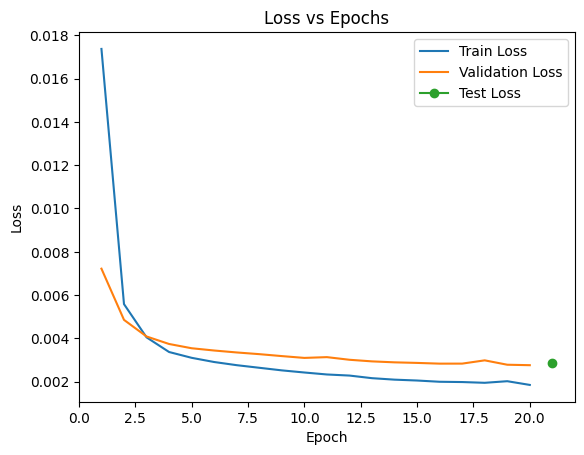

In [ ]:
# ——— Plot Loss vs Epochs ———
plt.figure()
plt.plot(range(1, len(train_losses)  + 1), train_losses,    label="Train Loss")
plt.plot(range(1, len(val_losses)    + 1), val_losses,      label="Validation Loss")
plt.plot(len(train_losses) + 1, avg_test_loss,              marker='o', label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.show()

The graph of training losses can be seen in the evaluation section but is included here for reference
#### Hyperparameter Justification
Learning Rate - Initially decided based on prior experience with deep learning models and then changed by factors of 10 until loss decreases steadily, forming the traditional curve seen with stable convergence. The model acheives it's goal with this learning rate, so no further changes were required.

Batch Size - A batch size of 64 was chosen initially as it gives a good balance of speed and stability. Larger batch sizes are not needed as, there is already a smooth curve with relativley short training times. Smaller batches will lead to less stable convergence.

Epochs - I chose to train for 20 epochs as that was a good starting points on early iterations of the model. This hasnt been changed as it hasn't needed to, the model achieves a validation SSIM greater than 0.9 early on and a basic state saving mechanism is employed so if the model does start overtraining the damage is mitigated. The SSIM is still increasing by epoch 20 so the model could be trained for longer, but as it has achieved it's goal already, there is no need.